In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import metrics
from sklearn.svm import SVC
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings('ignore')

In [74]:
data = pd.read_csv('Zillow.csv')
data.head()

,parcelid,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,...,fireplaceflag,structuretaxvaluedollarcnt,taxvaluedollarcnt,assessmentyear,landtaxvaluedollarcnt,taxamount,taxdelinquencyflag,taxdelinquencyyear,censustractandblock,target
0,14297519,NaN,NaN,NaN,3.5,4.0,NaN,NaN,3.5,NaN,...,NaN,485713.0,1023282.0,2016.0,537569.0,11013.72,NaN,NaN,6.059063e+13,0.025595
1,17052889,NaN,NaN,NaN,1.0,2.0,NaN,NaN,1.0,NaN,...,NaN,88000.0,464000.0,2016.0,376000.0,5672.48,NaN,NaN,6.111001e+13,0.055619
2,14186244,NaN,NaN,NaN,2.0,3.0,NaN,NaN,2.0,NaN,...,NaN,85289.0,564778.0,2016.0,479489.0,6488.30,NaN,NaN,6.059022e+13,0.005383
3,12177905,NaN,NaN,NaN,3.0,4.0,NaN,8.0,3.0,NaN,...,NaN,108918.0,145143.0,2016.0,36225.0,1777.51,NaN,NaN,6.037300e+13,-0.103410
4,10887214,1.0,NaN,NaN,3.0,3.0,NaN,8.0,3.0,NaN,...,NaN,73681.0,119407.0,2016.0,45726.0,1533.89,NaN,NaN,6.037124e+13,0.006940


In [75]:
data.shape

(77613, 59)

In [76]:
to_remove = []

for col in data.columns:

    # remove columns with only 1 unique answer
    if data[col].nunique() == 1:
        to_remove.append(col)

    # remove columns with more than 60% of rows as null values
    elif (data[col].isnull()).mean() > .60:
        to_remove.append(col)


print(len(to_remove))

30


In [77]:
data.drop(to_remove, axis=1, inplace=True)

In [78]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77613 entries, 0 to 77612
Data columns (total 29 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   parcelid                      77613 non-null  int64  
 1   bathroomcnt                   77579 non-null  float64
 2   bedroomcnt                    77579 non-null  float64
 3   buildingqualitytypeid         49809 non-null  float64
 4   calculatedbathnbr             76963 non-null  float64
 5   calculatedfinishedsquarefeet  77378 non-null  float64
 6   finishedsquarefeet12          73923 non-null  float64
 7   fips                          77579 non-null  float64
 8   fullbathcnt                   76963 non-null  float64
 9   heatingorsystemtypeid         49571 non-null  float64
 10  latitude                      77579 non-null  float64
 11  longitude                     77579 non-null  float64
 12  lotsizesquarefeet             69321 non-null  float64
 13  p

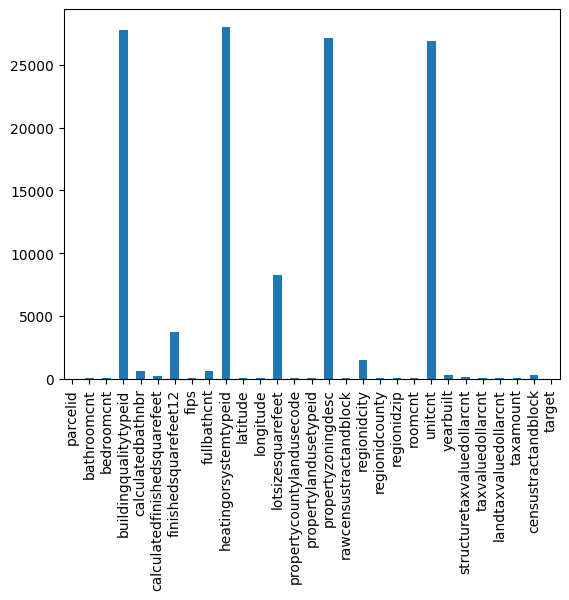

In [79]:
data.isnull().sum().plot(kind='bar')
plt.show()

In [80]:
for col in data.columns:
    if np.issubdtype(data[col].dtype, np.number):
        data[col] = data[col].fillna(data[col].mean())
    elif data[col].dtype == 'object':
        data[col] = data[col].fillna(data[col].mode()[0])

data.isnull().sum().sum()

np.int64(0)

In [81]:
ints, floats, objects = [],[],[]

for col in data.columns:
    if data[col].dtype == int:
        ints.append(col)
    elif data[col].dtype == float:
        floats.append(col)
    else:
        objects.append(col)

len(ints), len(floats), len(objects)

(1, 26, 2)

In [82]:
for col in objects:
    print(col, ' -> ', data[col].nunique())
    print(data[col].unique())
    print()

propertycountylandusecode  ->  75
['122' '1110' '0101' '010C' '1129' '0100' '38' '34' '1111' '012C' '010V'
 '1' '0103' '010D' '0200' '010E' '0300' '96' '0104' '0400' '01DC' '01HC'
 '1321' '1410' '0108' '1128' '010G' '1720' '010H' '1210' '0102' '010F'
 '010M' '1117' '0201' '0700' '1722' '73' '0109' '0301' '01HE' '135' '0204'
 '0401' '070D' '0113' '0133' '0131' '1432' '040G' '1112' '1222' '1310'
 '1120' '0111' '1116' '1421' '0110' '0105' '012E' '0141' '1333' '0115'
 '040V' '010L' '040B' '012D' '0114' '0203' '030G' '0130' '105' '020G'
 '020M' '020E']

propertyzoningdesc  ->  1907
['LAR1' 'LCR110000*' 'LAR3' ... 'HAR4-R2*' 'LCR1VV' 'BFA15000*']



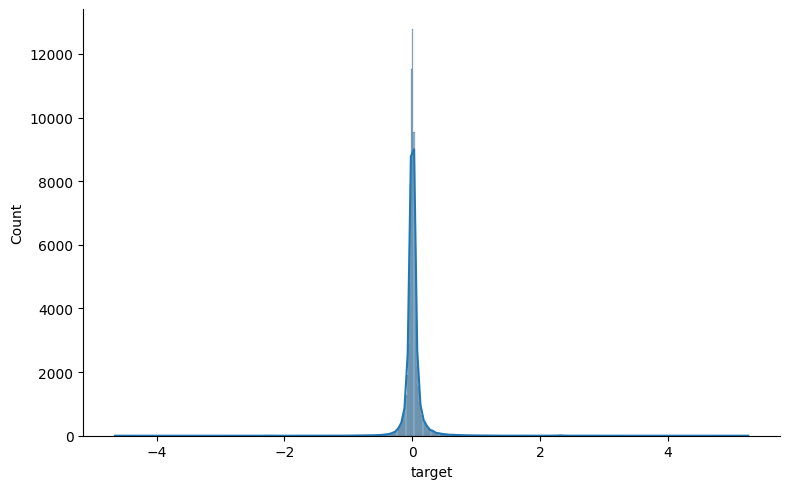

In [83]:
sns.displot(data['target'], kde=True, height=5, aspect=1.6)
plt.show()

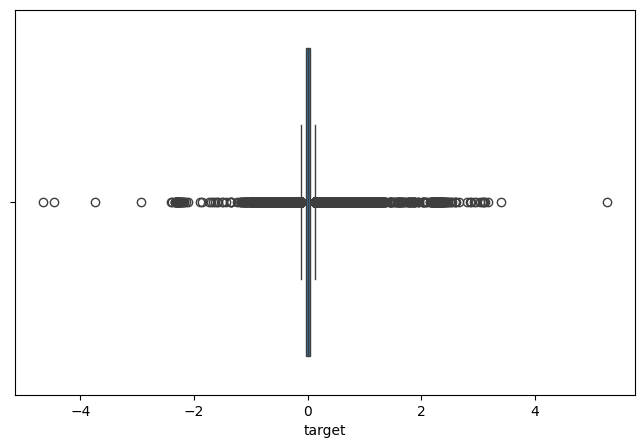

In [84]:
plt.figure(figsize=(8,5))
sns.boxplot(data['target'], orient='h')
plt.show()

In [85]:
print('Shape of the dataframe before removal of outliers', data.shape)
data = data[(data['target'] > -1) & (data['target'] < 1)]
print('Shape of the dataframe after removal of outliers ', data.shape)

Shape of the dataframe before removal of outliers (77613, 29)
Shape of the dataframe after removal of outliers  (77261, 29)


In [87]:
for col in objects:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])

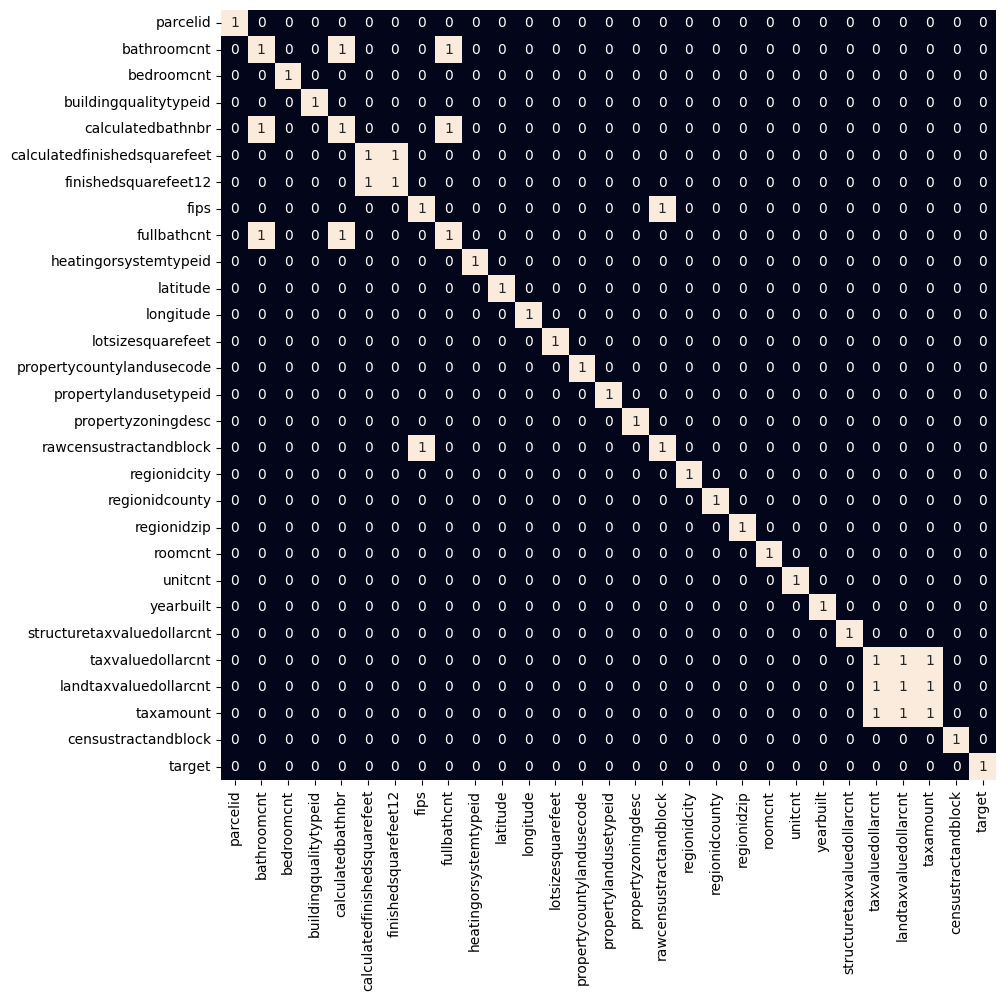

In [90]:
plt.figure(figsize=(10, 10))
sns.heatmap(data.corr() > 0.8,
           annot=True,
           cbar=False)
plt.show()

In [91]:
to_remove = ['calculatedbathnbr', 'fullbathcnt', 'fips',
             'rawcensustractandblock', 'taxvaluedollarcnt',
             'finishedsquarefeet12', 'landtaxvaluedollarcnt']

data.drop(to_remove, axis=1, inplace=True)

In [97]:
features = data.drop(['parcelid'], axis=1)
target = data['target'].values

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

X_train.shape, X_test.shape

((61808, 21), (15453, 21))

In [98]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [101]:
from sklearn.metrics import mean_absolute_error as mae
models = [LinearRegression(), XGBRegressor(), Lasso(), RandomForestRegressor(), Ridge()]

for i in range(len(models)):
    models[i].fit(X_train, y_train)

    print(type(models[i]).__name__, ":")

    train_preds = models[i].predict(X_train)
    print('Training Error : ', mae(y_train, train_preds))

    test_preds = models[i].predict(X_test)
    print('Testing Error : ', mae(y_test, test_preds))
    print()

LinearRegression :
Training Error :  0.061950041044795526
Testing Error :  0.06285616854788019

XGBRegressor :
Training Error :  0.0010800316330904624
Testing Error :  0.0023811544300148565

Lasso :
Training Error :  0.06192114104756583
Testing Error :  0.0628279623081523

RandomForestRegressor :
Training Error :  9.950828821695621e-06
Testing Error :  2.5137135782535728e-05

Ridge :
Training Error :  7.73101756283308e-05
Testing Error :  7.848280311922173e-05

